This block imports necessary libraries: `random` for random number generation, `numpy` for numerical operations, and `matplotlib.pyplot` for plotting. These are fundamental libraries for data manipulation and visualization in Python.

In [8]:
import random
import numpy as np
import matplotlib.pyplot as plt

This cell generates 200 random numbers, uniformly distributed between -3 and 3, which will serve as our feature `X`. The `reshape(200, 1)` ensures `X` is a 2D array, suitable for scikit-learn models.

In [14]:
X = 6 * np.random.rand(200, 1) - 3

Here, the target variable `Y` is generated based on `X` using a quadratic relationship: `0.8 * X^2 + 0.7 * X + 2`. Additionally, `np.random.rand(200, 1)` adds some random noise to `Y`, making the data more realistic and less perfectly correlated, which is typical in real-world datasets.

In [30]:
Y = 0.8*( X **2 ) + 0.7 * X + 2 + np.random.rand(200,1)

This cell creates an initial scatter plot of `X` against `Y`. This visualization helps to understand the underlying relationship between the feature and the target variable, which in this case clearly shows a non-linear, parabolic pattern.

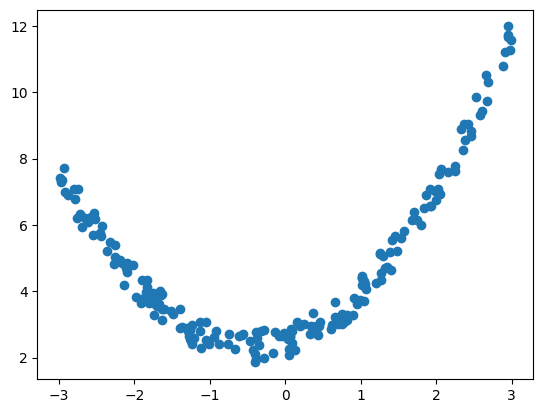

In [31]:
plt.scatter(X,Y)
plt.show()

This cell imports the `LinearRegression` model from `sklearn.linear_model` and initializes an instance of it. This model will be used to perform simple linear regression on our data.

In [32]:
from sklearn.linear_model import LinearRegression
Linear_regression = LinearRegression()

Here, the linear regression model is trained (fitted) using our generated `X` and `Y` data. The model learns the best-fit straight line that minimizes the sum of squared errors between the predicted and actual `Y` values.

In [33]:
Linear_regression.fit(X , Y)

LinearRegression()

After training, this cell uses the `Linear_regression` model to predict `Y` values based on the original `X` data. These predictions (`linear_y`) represent the best-fit straight line generated by the model.

In [34]:
linear_y = Linear_regression.predict(X)

This cell imports the `r2_score` metric from `sklearn.metrics` and then calculates and prints the R2-score for the linear regression model. The R2-score, also known as the coefficient of determination, indicates the proportion of variance in the dependent variable that can be predicted from the independent variable(s).

In [36]:
from sklearn.metrics import r2_score
print(f"R2 - score using Linear regression is {r2_score(Y , linear_y)}")

R2 - score using Linear regression is 0.18142913580445674


This cell visualizes the results of the linear regression. It plots the original data points (`X`, `Y`) as a scatter plot and overlays the red line representing the linear regression model's predictions (`X`, `linear_y`), showing how well a straight line fits the non-linear data.

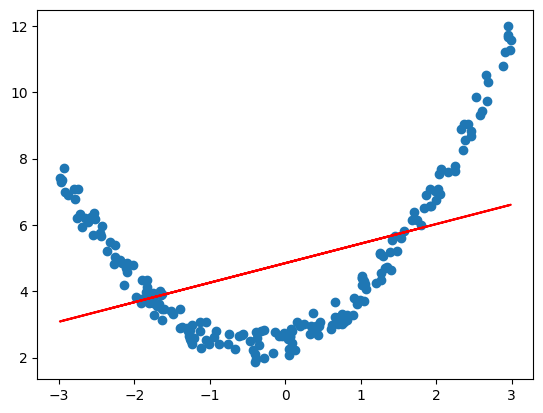

In [38]:
plt.scatter(X,Y)
plt.plot(X , linear_y , color = "red")
plt.show()

To address the non-linear relationship observed earlier, this cell imports `PolynomialFeatures` from `sklearn.preprocessing`. It initializes a `poly` object to transform the input features into polynomial features of `degree=2` (i.e., it will create `X^2` terms), and `include_bias=True` adds an intercept term.

In [48]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 2 , include_bias= True)

This cell applies the polynomial transformation to the original `X` data using `poly.fit_transform(X)`. The resulting `X_poly` now contains `X` and `X^2` terms, allowing a linear model to capture quadratic relationships.

In [49]:
X_poly = poly.fit_transform(X)

Here, the `LinearRegression` model is re-trained (fitted) but this time using the transformed polynomial features (`X_poly`) instead of the original `X`. This effectively performs polynomial regression, as the linear model now operates on a higher-dimensional feature space.

In [59]:
Linear_regression.fit(X_poly , Y)

LinearRegression()

This cell generates a new set of `X` values (`X_new`) spanning the same range for smoother plotting. These `X_new` values are then transformed into polynomial features (`X_new_poly`) using the same `poly` transformer, and finally, the polynomial regression model predicts the corresponding `Y` values (`y_linear_poly`).

In [61]:
X_new = np.linspace(-3 , 3, 200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_linear_poly = Linear_regression.predict(X_new_poly)

This cell calculates the R2-score for the polynomial regression model. It compares the actual `Y` values with the predicted `y_linear_poly` values (which were predicted on `X_new`). Note: For a precise R2-score on the training data, predictions should ideally be made on the `X_poly` that was used for training (i.e., `Linear_regression.predict(X_poly)`).

In [60]:
r2_score(Y , y_linear_poly)

0.9848321829680762

This final visualization cell provides a comprehensive comparison. It plots the original data, the linear regression line (in red), and the polynomial regression curve (in green). The legend helps distinguish between the two models, clearly demonstrating how polynomial regression better captures the underlying non-linear pattern in the data.

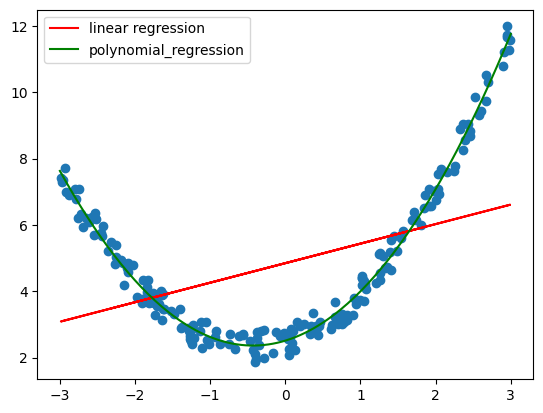

In [67]:
plt.scatter(X,Y)
plt.plot(X , linear_y , color = "red" , label = "linear regression")
plt.plot(X_new , y_linear_poly , color = "green" , label = "polynomial_regression")
plt.legend()
plt.show()